# Caution

This notebook uses the newer side-symmetric triple-barrier labeler, but the synthetic DGP is still calibrated to equal-weight portfolio volatility. Interpret label noise and economic deltas together with `fundamental0.ipynb` and `fundamental1.ipynb`. The secondary strategy shown here may still be gross-exposure normalised rather than dollar-neutral.


# Horizon Sensitivity Diagnostics

This notebook studies why changing the triple-barrier horizon can improve classification metrics more visibly than economic metrics.

The core idea is simple but important: different triple-barrier horizons create different labels. A 30-day label and a 150-day label are related, but they do not ask exactly the same classification question. Therefore, horizon comparisons are useful, but they should not be interpreted as if we were only comparing two hyperparameters of the same unchanged target.

The notebook keeps the actual strategy evaluation daily rebalanced, while adding event-level diagnostics over multiple forward payoff windows. This separates label clarity, trade selection, payoff timing, and portfolio exposure.

## Motivation

### Question

The main question is why longer triple-barrier horizons can produce much better classification metrics while producing only moderate, unstable, or even negative economic improvements.

### Prior Evidence

Previous runs already suggested that longer horizons make the labels clearer. This is intuitive in the synthetic setting: stocks with positive or negative drift accumulate directional signal over time, while random noise grows more slowly in relative terms.

### Important Caveat

A longer horizon does not merely change a model setting. It changes the target variable. A model that predicts 150-day barrier outcomes well may still be poorly aligned with a daily-rebalanced portfolio objective.

### Current Diagnostic Focus

The notebook therefore asks:

- Are longer-horizon labels easier to rank?
- Does the secondary model keep better trades?
- Are false positives economically costly?
- Are filtered trades mostly avoided losers or missed winners?
- Does any signal appear only at longer payoff windows?
- Does gross-exposure normalisation create long/short exposure imbalance?

## Setup

The imports reuse the fast workflow: fast primary strategy, fast triple-barrier labels, fast secondary model, and the existing evaluation function.

The additional sensitivity helper module handles event-level payoff windows, confusion groups, expectancy, filtering effects, long/short side diagnostics, and exposure summaries.

In [153]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.primary_strategy import build_primary_momentum_strategy_fast
from src.triple_barrier_lsymmetric import simple_triple_barrier_labels_lsymmetric
from src.secondary_model_fast import (
    build_secondary_dataset_fast,
    purged_time_split,
    fit_logistic,
    apply_probability_threshold,
    threshold_diagnostics,
    create_filtered_weights_fast,
    calculate_strategy_pnl,
)
from src.evaluation_metrics import evaluate_strategy
from src.horizon_sensitivity import (
    attach_payoff_windows,
    add_confusion_groups,
    expectancy_summary,
    confusion_payoff_summary,
    filtering_effect_summary,
    side_diagnostics,
    exposure_summary,
)

plt.style.use("default")
pd.options.display.float_format = "{:.4f}".format

## Data-Generation Specification

This cell defines the synthetic universe used by the fast workflow:

- 500 stocks
- 10,000 business days
- factor and specific covariance components
- a subset of stocks with positive drift and a subset with negative drift

The key experiment is controlled by `n_up` and `n_down` in the next section. Running `200u / 100d`, `100u / 200d`, and `150u / 150d` is especially useful because it tests whether the secondary strategy's exposure drift follows the dominant simulated side or whether it has a structural side tendency.

In [154]:
component_seed = 0
rng_components = np.random.default_rng(component_seed)

N = 500
T = 10_000
K = 10

dates = pd.date_range("1986-01-01", periods=T, freq="B")
cols = [f"Stock_{i:03d}" for i in range(N)]

target_daily_vol = 0.10 / np.sqrt(252)
split = [0.6, 0.4]
trend_daily = 0.50 / 252

wi = np.ones((N, 1)) / N

Z = rng_components.normal(0, 1, size=(N, K - 1))
Z = (Z - Z.mean(axis=1, keepdims=True)) / Z.std(axis=1, keepdims=True)
Z = np.concatenate([rng_components.uniform(0.5, 1.5, size=(N, 1)), Z], axis=1)

G = np.diag(np.concatenate([np.ones(1), [0.25 * np.exp(-i) for i in range(K - 1)]]))
S = rng_components.uniform(0.01, 0.25, size=N)

multf = np.squeeze(split[0] * target_daily_vol**2 / (wi.T @ (Z @ G @ Z.T) @ wi))
mults = np.squeeze(split[1] * target_daily_vol**2 / (wi.T @ np.diag(S) @ wi))

G = multf * G
cov_factor = Z @ G @ Z.T
S = mults * S
cov_specific = np.diag(S)
cov = cov_factor + cov_specific

beta = (np.eye(N) @ cov @ wi) / (wi.T @ cov @ wi)

## Simulation Configuration

### Main Inputs

Change `n_up` and `n_down` to run the asymmetric or balanced scenarios.

Recommended comparison runs:

- `n_up = 200`, `n_down = 100`
- `n_up = 100`, `n_down = 200`
- `n_up = 150`, `n_down = 150`

The default `n_sims = 20` keeps runtime manageable. For final thesis figures, increase it to `50` once the notebook structure is stable.

### Feature Set

This run uses the side-aware feature set:

\[
\text{features} = \{\text{side}, \text{abs weight}, \text{signed ret}_{150}, \text{vol}_{150}\}
\]

The purpose is to test whether explicitly separating side from signal strength improves the secondary model. Here, `side` captures long versus short direction, `abs_weight` captures primary signal strength, and `signed_ret_150` measures past return in the direction of the proposed trade.

In [155]:
n_sims = 20
base_seed = 20_000

n_up = 100
n_down = 200
scenario_name = f"{n_up}u/{n_down}d"

horizons = [30, 60, 90, 150]
payoff_windows = sorted(set([1, 5, 20, 30, 60, 150] + horizons))

lookback = 260
barrier_vol_window = 20
secondary_window = 150
threshold = 0.50

train_frac = 0.50
val_frac = 0.25

feature_cols = [
    "side",
    "abs_weight",
    f"signed_ret_{secondary_window}",
    f"vol_{secondary_window}",
]

scenario_name, horizons, payoff_windows, feature_cols

('100u/200d',
 [30, 60, 90, 150],
 [1, 5, 20, 30, 60, 90, 150],
 ['side', 'abs_weight', 'signed_ret_150', 'vol_150'])

## Notebook Helpers

These small helpers keep the simulation loop readable.

The threshold is fixed at `0.50` to avoid mixing horizon sensitivity with threshold selection. Later, threshold choice can be studied separately.

In [156]:
def sample_returns(seed):
    rng = np.random.default_rng(seed)

    up_stocks = rng.choice(N, size=n_up, replace=False)
    remaining = np.setdiff1d(np.arange(N), up_stocks)
    down_stocks = rng.choice(remaining, size=n_down, replace=False)

    trend = np.zeros(N)
    trend[up_stocks] = rng.uniform(0.1, 1.0, size=n_up) * trend_daily
    trend[down_stocks] = -rng.uniform(0.1, 1.0, size=n_down) * trend_daily

    sampled_returns = rng.multivariate_normal(trend, cov, size=T)
    return pd.DataFrame(sampled_returns, index=dates, columns=cols)


def metric_value(summary, metric):
    value = summary.loc[summary["Metric"] == metric, "Value"]
    return np.nan if value.empty else float(value.iloc[0])


def safe_roc_auc(df):
    if df["label"].nunique() < 2:
        return np.nan
    return roc_auc_score(df["label"], df["probability"])


def positive_filter_stats(filtered_df):
    y_true = filtered_df["label"]
    y_pred = filtered_df["meta_label"]

    positive_total = int((y_true == 1).sum())
    positive_kept = int(((y_true == 1) & (y_pred == 1)).sum())
    positive_filtered = int(((y_true == 1) & (y_pred == 0)).sum())

    if positive_total > 0:
        positive_kept_rate = positive_kept / positive_total
        positive_filtered_rate = positive_filtered / positive_total
    else:
        positive_kept_rate = np.nan
        positive_filtered_rate = np.nan

    return {
        "positive_total": positive_total,
        "positive_kept": positive_kept,
        "positive_filtered": positive_filtered,
        "positive_kept_rate": positive_kept_rate,
        "positive_filtered_rate": positive_filtered_rate,
    }


def selected_strategy_metrics(summary, prefix):
    return {
        f"{prefix}_ann_return": metric_value(summary, "Annualized return"),
        f"{prefix}_avg_daily_return": metric_value(summary, "Average daily return"),
        f"{prefix}_sharpe": metric_value(summary, "Sharpe ratio"),
        f"{prefix}_max_drawdown": metric_value(summary, "Maximum drawdown"),
        f"{prefix}_ann_turnover": metric_value(summary, "Annualized turnover"),
    }


def standardize_gross_exposure(filtered_weights, primary_weights):
    primary_exposure = primary_weights.abs().sum(axis=1)
    filtered_exposure = filtered_weights.abs().sum(axis=1)
    scale = primary_exposure / filtered_exposure
    scale = scale.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return filtered_weights.mul(scale, axis=0)


def tidy_strategy_deltas(row):
    row["delta_ann_return"] = row["secondary_ann_return"] - row["primary_ann_return"]
    row["delta_avg_daily_return"] = row["secondary_avg_daily_return"] - row["primary_avg_daily_return"]
    row["delta_sharpe"] = row["secondary_sharpe"] - row["primary_sharpe"]
    row["delta_max_drawdown"] = row["secondary_max_drawdown"] - row["primary_max_drawdown"]
    row["delta_ann_turnover"] = row["secondary_ann_turnover"] - row["primary_ann_turnover"]
    return row


def add_metadata(df, sim, seed, horizon):
    out = df.copy()
    out.insert(0, "horizon", horizon)
    out.insert(0, "seed", seed)
    out.insert(0, "sim", sim)
    out.insert(0, "scenario", scenario_name)
    return out


def plot_payoff_panel(summary_df, title, group_col=None, group_value=None):
    if group_col is not None:
        plot_df = summary_df[summary_df[group_col] == group_value].copy()
    else:
        plot_df = summary_df.copy()

    plot_df = (
        plot_df
        .groupby(["horizon", "window"])[["win_rate", "avg_win", "avg_abs_loss", "expectancy"]]
        .mean()
        .reset_index()
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    plot_metrics = [
        ("win_rate", "Win rate"),
        ("avg_win", "Average win"),
        ("avg_abs_loss", "Average absolute loss"),
        ("expectancy", "Expectancy"),
    ]

    for ax, (metric, metric_title) in zip(axes.ravel(), plot_metrics):
        for horizon in horizons:
            data = plot_df[plot_df["horizon"] == horizon]
            ax.plot(data["window"], data[metric], marker="o", label=f"{horizon}d")
        ax.set_title(metric_title)
        ax.set_xlabel("Forward payoff window")
        ax.grid(alpha=0.25)

    axes[0, 0].legend(title="Label horizon")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

    return plot_df

## Single-Horizon Pipeline

For each seed and horizon, this function runs the full fast pipeline.

### What It Returns

The output is split into tidy tables:

- classification diagnostics
- strategy metrics
- confusion counts
- payoff expectancy by decision and window
- payoff expectancy by TP/FP/TN/FN group
- filtering effects
- long/short side diagnostics
- exposure diagnostics

The strategy evaluation remains daily rebalanced. The event-level payoff windows are diagnostic tools, not a change in portfolio rebalancing frequency.

In [157]:
def run_one_horizon_sim(sim, seed, horizon, df_returns, primary_pnl, wt):
    labels = simple_triple_barrier_labels_lsymmetric(
        df_returns=df_returns,
        wt=wt,
        horizon=horizon,
        vol_window=barrier_vol_window,
    )

    secondary_data = build_secondary_dataset_fast(
        df_returns=df_returns,
        labels=labels,
        window=secondary_window,
    )

    train_df, val_df, test_df, val_start, test_start = purged_time_split(
        df=secondary_data,
        horizon=horizon,
        train_frac=train_frac,
        val_frac=val_frac,
    )

    model, train_pred_df, val_pred_df, test_pred_df = fit_logistic(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
    )

    test_filtered_df = apply_probability_threshold(test_pred_df, threshold)
    test_dates = pd.Index(test_filtered_df["t0"].unique())
    test_dates = test_dates.intersection(wt.index).intersection(df_returns.index).sort_values()
    test_filtered_df = test_filtered_df[test_filtered_df["t0"].isin(test_dates)].copy()

    test_threshold_summary = threshold_diagnostics(test_filtered_df)
    positive_stats = positive_filter_stats(test_filtered_df)

    primary_test_wt = wt.reindex(test_dates)
    primary_test_pnl = calculate_strategy_pnl(primary_test_wt, df_returns)
    primary_summary = evaluate_strategy(primary_test_pnl, primary_test_wt)

    secondary_test_wt_raw = create_filtered_weights_fast(
        primary_weights=primary_test_wt,
        filtered_df=test_filtered_df,
    )
    secondary_test_wt = standardize_gross_exposure(
        filtered_weights=secondary_test_wt_raw,
        primary_weights=primary_test_wt,
    )
    secondary_test_pnl = calculate_strategy_pnl(secondary_test_wt, df_returns)
    secondary_summary = evaluate_strategy(secondary_test_pnl, secondary_test_wt)

    event_df = attach_payoff_windows(
        df_returns=df_returns,
        events_df=test_filtered_df,
        windows=payoff_windows,
    )
    event_df = add_confusion_groups(event_df)
    event_df["decision"] = np.where(event_df["kept"], "kept", "filtered")

    classification_row = {
        "scenario": scenario_name,
        "sim": sim,
        "seed": seed,
        "horizon": horizon,
        "roc_auc": safe_roc_auc(test_filtered_df),
        "base_positive_rate": metric_value(test_threshold_summary, "Base positive rate"),
        "positive_rate_among_kept": metric_value(test_threshold_summary, "Positive rate among kept trades"),
        "fraction_kept": metric_value(test_threshold_summary, "Fraction kept"),
        "test_trades": len(test_filtered_df),
        **positive_stats,
    }

    strategy_row = {
        "scenario": scenario_name,
        "sim": sim,
        "seed": seed,
        "horizon": horizon,
        **selected_strategy_metrics(primary_summary, "primary"),
        **selected_strategy_metrics(secondary_summary, "secondary"),
    }
    strategy_row = tidy_strategy_deltas(strategy_row)

    confusion_counts = event_df["confusion_group"].value_counts().reindex(["TP", "FP", "TN", "FN"], fill_value=0)
    confusion_row = {
        "scenario": scenario_name,
        "sim": sim,
        "seed": seed,
        "horizon": horizon,
        "total_events": len(event_df),
        **{f"{group}_count": int(count) for group, count in confusion_counts.items()},
        **{f"{group}_share": count / len(event_df) for group, count in confusion_counts.items()},
    }

    expectancy_rows = []
    confusion_payoff_rows = []
    filtering_rows = []
    side_rows = []

    for window in payoff_windows:
        for payoff_type, payoff_col in [
            ("side", f"side_payoff_{window}d"),
            ("weight", f"weight_payoff_{window}d"),
        ]:
            expectancy = expectancy_summary(
                df=event_df,
                payoff_col=payoff_col,
                group_col="decision",
            )
            expectancy["window"] = window
            expectancy["payoff_type"] = payoff_type
            expectancy_rows.append(expectancy)

            confusion_payoff = confusion_payoff_summary(
                df=event_df,
                payoff_col=payoff_col,
            )
            confusion_payoff["window"] = window
            confusion_payoff["payoff_type"] = payoff_type
            confusion_payoff_rows.append(confusion_payoff)

            side_diag = side_diagnostics(
                df=event_df,
                payoff_col=payoff_col,
            )
            side_diag["window"] = window
            side_diag["payoff_type"] = payoff_type
            side_rows.append(side_diag)

        filtering = filtering_effect_summary(
            df=event_df,
            payoff_col=f"weight_payoff_{window}d",
        )
        filtering["window"] = window
        filtering_rows.append(filtering)

    expectancy_df = pd.concat(expectancy_rows, ignore_index=True)
    confusion_payoff_df = pd.concat(confusion_payoff_rows, ignore_index=True)
    filtering_df = pd.concat(filtering_rows, ignore_index=True)
    side_df = pd.concat(side_rows, ignore_index=True)

    primary_exposure = exposure_summary(primary_test_wt).mean().to_dict()
    secondary_exposure = exposure_summary(secondary_test_wt).mean().to_dict()
    exposure_df = pd.DataFrame([
        {"strategy": "primary", **primary_exposure},
        {"strategy": "secondary_gross", **secondary_exposure},
    ])

    return {
        "classification": pd.DataFrame([classification_row]),
        "strategy": pd.DataFrame([strategy_row]),
        "confusion": pd.DataFrame([confusion_row]),
        "expectancy": add_metadata(expectancy_df, sim, seed, horizon),
        "confusion_payoff": add_metadata(confusion_payoff_df, sim, seed, horizon),
        "filtering": add_metadata(filtering_df, sim, seed, horizon),
        "side": add_metadata(side_df, sim, seed, horizon),
        "exposure": add_metadata(exposure_df, sim, seed, horizon),
    }

## Horizon Simulation Loop

Each simulation seed generates one return matrix. The same return matrix is then reused across all horizons. This makes the horizon comparison cleaner because differences across horizons are not driven by different random samples.

In [158]:
classification_parts = []
strategy_parts = []
confusion_parts = []
expectancy_parts = []
confusion_payoff_parts = []
filtering_parts = []
side_parts = []
exposure_parts = []
error_rows = []

total_runs = n_sims * len(horizons)
completed_runs = 0

for sim in range(n_sims):
    seed = base_seed + sim
    df_returns = sample_returns(seed)
    primary_pnl, wt, signal = build_primary_momentum_strategy_fast(
        df_returns=df_returns,
        lookback=lookback,
    )

    for horizon in horizons:
        try:
            outputs = run_one_horizon_sim(
                sim=sim,
                seed=seed,
                horizon=horizon,
                df_returns=df_returns,
                primary_pnl=primary_pnl,
                wt=wt,
            )
            classification_parts.append(outputs["classification"])
            strategy_parts.append(outputs["strategy"])
            confusion_parts.append(outputs["confusion"])
            expectancy_parts.append(outputs["expectancy"])
            confusion_payoff_parts.append(outputs["confusion_payoff"])
            filtering_parts.append(outputs["filtering"])
            side_parts.append(outputs["side"])
            exposure_parts.append(outputs["exposure"])
        except Exception as exc:
            error_rows.append({
                "scenario": scenario_name,
                "sim": sim,
                "seed": seed,
                "horizon": horizon,
                "error": str(exc),
            })

        completed_runs += 1
        if completed_runs % max(1, total_runs // 10) == 0:
            print(f"completed {completed_runs}/{total_runs}")

classification_results = pd.concat(classification_parts, ignore_index=True) if classification_parts else pd.DataFrame()
strategy_results = pd.concat(strategy_parts, ignore_index=True) if strategy_parts else pd.DataFrame()
confusion_results = pd.concat(confusion_parts, ignore_index=True) if confusion_parts else pd.DataFrame()
expectancy_results = pd.concat(expectancy_parts, ignore_index=True) if expectancy_parts else pd.DataFrame()
confusion_payoff_results = pd.concat(confusion_payoff_parts, ignore_index=True) if confusion_payoff_parts else pd.DataFrame()
filtering_results = pd.concat(filtering_parts, ignore_index=True) if filtering_parts else pd.DataFrame()
side_results = pd.concat(side_parts, ignore_index=True) if side_parts else pd.DataFrame()
exposure_results = pd.concat(exposure_parts, ignore_index=True) if exposure_parts else pd.DataFrame()
error_results = pd.DataFrame(error_rows)

classification_results.head(), error_results.head()

completed 8/80
completed 16/80
completed 24/80
completed 32/80
completed 40/80
completed 48/80
completed 56/80
completed 64/80
completed 72/80
completed 80/80


(    scenario  sim   seed  horizon  roc_auc  base_positive_rate  \
 0  100u/200d    0  20000       30   0.5096              0.2960   
 1  100u/200d    0  20000       60   0.5136              0.3086   
 2  100u/200d    0  20000       90   0.5195              0.3139   
 3  100u/200d    0  20000      150   0.5291              0.3164   
 4  100u/200d    1  20001       30   0.5110              0.2957   
 
    positive_rate_among_kept  fraction_kept  test_trades  positive_total  \
 0                    0.3025         0.4849      1214000          359341   
 1                    0.3179         0.4789      1210000          373443   
 2                    0.3269         0.4782      1206500          378697   
 3                    0.3359         0.4737      1199000          379408   
 4                    0.3013         0.5156      1214000          358960   
 
    positive_kept  positive_filtered  positive_kept_rate  \
 0         178103             181238              0.4956   
 1         184228 

## Classification Comparison

### What Is Compared

The plots below compare ROC AUC, base positive rate, positive rate among kept trades, and fraction kept across label horizons.

### Why The Comparison Needs Care

Changing the horizon changes the label definition. Therefore, the comparison is not the same as comparing two models on the exact same target.

### What To Look For

A useful horizon should not only improve ROC AUC. It should also produce kept trades with better payoff expectancy and should not create problematic exposure imbalance.

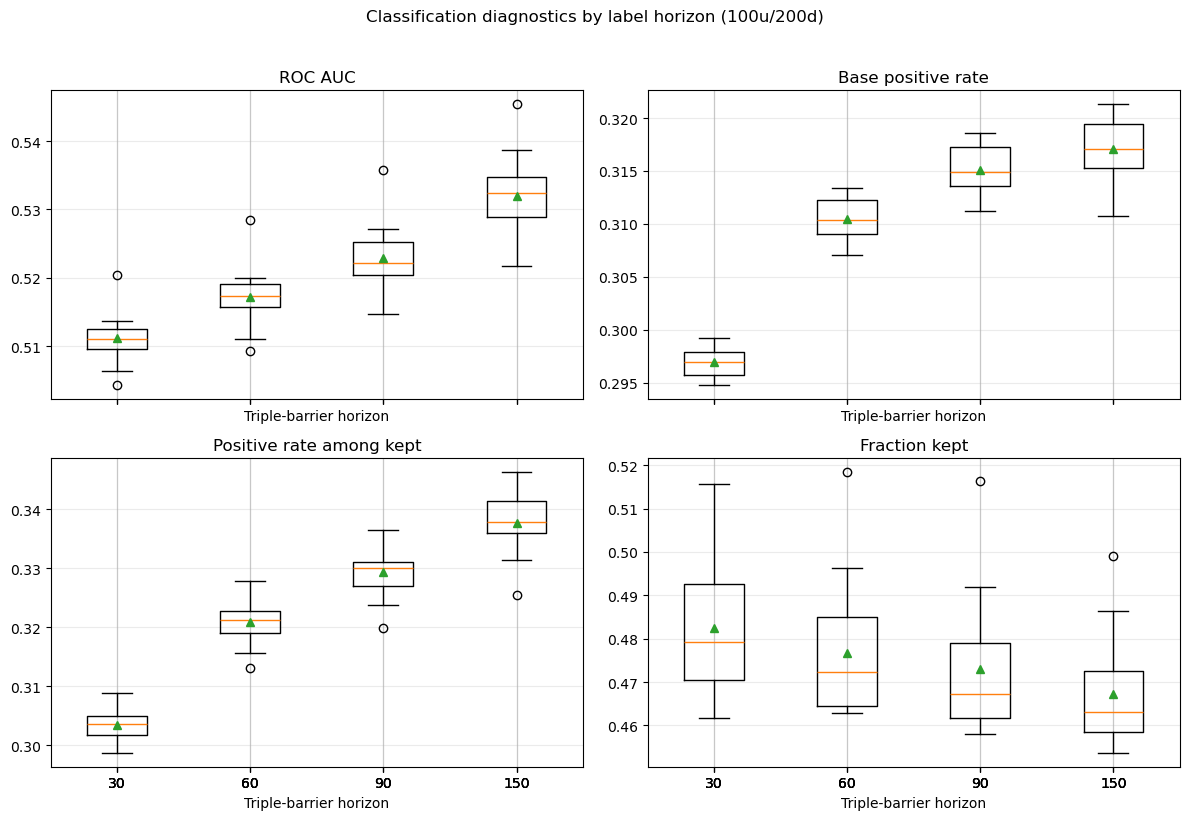

In [159]:
classification_metrics = [
    ("roc_auc", "ROC AUC"),
    ("base_positive_rate", "Base positive rate"),
    ("positive_rate_among_kept", "Positive rate among kept"),
    ("fraction_kept", "Fraction kept"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, (metric, title) in zip(axes, classification_metrics):
    data = [
        classification_results.loc[classification_results["horizon"] == horizon, metric].dropna()
        for horizon in horizons
    ]
    ax.boxplot(data, labels=horizons, showmeans=True)
    ax.set_title(title)
    ax.set_xlabel("Triple-barrier horizon")
    ax.grid(alpha=0.25)

fig.suptitle(f"Classification diagnostics by label horizon ({scenario_name})", y=1.02)
fig.tight_layout()
plt.show()

In [160]:
classification_summary = (
    classification_results
    .groupby("horizon")[[
        "roc_auc",
        "base_positive_rate",
        "positive_rate_among_kept",
        "fraction_kept",
        "positive_kept_rate",
        "positive_filtered_rate",
    ]]
    .agg(["mean", "std"])
)

classification_summary

roc_auc        base_positive_rate        positive_rate_among_kept  \
           mean    std               mean    std                     mean   
horizon                                                                     
30       0.5111 0.0032             0.2969 0.0013                   0.3035   
60       0.5171 0.0039             0.3104 0.0019                   0.3208   
90       0.5228 0.0045             0.3151 0.0022                   0.3293   
150      0.5320 0.0053             0.3171 0.0029                   0.3377   

               fraction_kept        positive_kept_rate         \
           std          mean    std               mean    std   
horizon                                                         
30      0.0024        0.4825 0.0155             0.4932 0.0170   
60      0.0033        0.4767 0.0149             0.4927 0.0164   
90      0.0037        0.4730 0.0146             0.4943 0.0160   
150     0.0046        0.4673 0.0120             0.4978 0.0148   

        positive_filtered_rate         
                          mean    std  
horizon                                
30                      0.5068 0.0170  
60                      0.5073 0.0164  
90                      0.5057 0.0160  
150                     0.5022 0.0148

## Confusion Matrix And Filtering Decomposition

### Confusion Groups

The secondary model makes a binary keep/filter decision. Combining that decision with the triple-barrier label gives four groups:

- **TP**: positive-label trades that were kept
- **FP**: negative-label trades that were kept
- **TN**: negative-label trades that were filtered
- **FN**: positive-label trades that were filtered

### Economic Interpretation

The confusion matrix is useful because meta-labeling can add value in two ways:

- keeping good trades
- filtering bad trades

It can also lose value in two ways:

- keeping bad trades
- filtering good trades

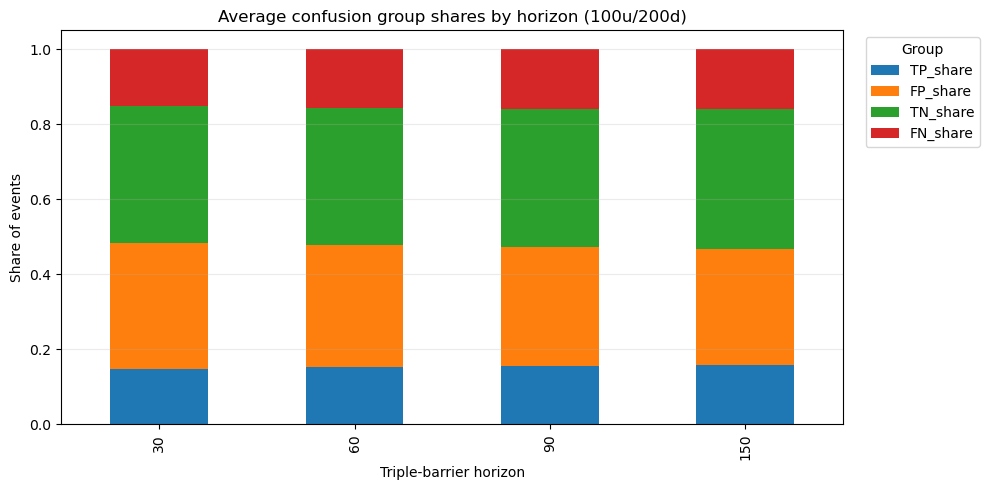

,TP_share,FP_share,TN_share,FN_share
horizon,,,,
30,0.1464,0.3361,0.3670,0.1505
60,0.1529,0.3238,0.3658,0.1575
90,0.1558,0.3173,0.3676,0.1594
150,0.1578,0.3095,0.3735,0.1592


In [161]:
share_cols = ["TP_share", "FP_share", "TN_share", "FN_share"]
confusion_share_summary = confusion_results.groupby("horizon")[share_cols].mean()

ax = confusion_share_summary.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title(f"Average confusion group shares by horizon ({scenario_name})")
ax.set_xlabel("Triple-barrier horizon")
ax.set_ylabel("Share of events")
ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

confusion_share_summary

In [162]:
filtering_1d = filtering_results[filtering_results["window"] == 1]
filtering_summary_1d = (
    filtering_1d
    .groupby(["horizon", "decision", "label_group"])[[
        "n",
        "avg_payoff",
        "total_payoff",
        "avg_filtering_effect",
        "total_filtering_effect",
    ]]
    .mean()
    .reset_index()
)

filtering_summary_1d

,horizon,decision,label_group,n,avg_payoff,total_payoff,avg_filtering_effect,total_filtering_effect
0,30,filtered,negative_label,445519.3000,-0.0000,-8.8988,0.0000,8.8988
1,30,filtered,positive_label,182670.4500,0.0000,8.8544,-0.0000,-8.8544
2,30,kept,negative_label,408032.2500,-0.0000,-9.5924,0.0000,0.0000
3,30,kept,positive_label,177778.0000,0.0001,10.1375,0.0000,0.0000
4,60,filtered,negative_label,442611.4000,-0.0000,-7.0296,0.0000,7.0296
5,60,filtered,positive_label,190553.6000,0.0000,7.0092,-0.0000,-7.0092
6,60,kept,negative_label,391765.5500,-0.0000,-6.9049,0.0000,0.0000
7,60,kept,positive_label,185069.4500,0.0000,7.4257,0.0000,0.0000
8,90,filtered,negative_label,443516.5500,-0.0000,-6.1914,0.0000,6.1914
9,90,filtered,positive_label,192256.6000,0.0000,6.2070,-0.0000,-6.2070


## How To Read The Payoff Diagnostics

The payoff diagnostics decompose realised trade outcomes into four quantities: win rate, average win, average absolute loss, and expectancy. These are computed for groups such as kept trades, filtered trades, true positives, false positives, true negatives, and false negatives.

### Win Rate

The **win rate** measures how often trades in a given group produce a positive realised payoff.

For a selected group of trades \(G\), define:

$$
\text{win rate}
=
\frac{
    \#\{i \in G : \text{payoff}_i > 0\}
}{
    \#\{i \in G\}
}
$$

Intuitively, this answers: *how often does this group of trades make money?*

A higher win rate is generally desirable, but it is not sufficient by itself because it ignores the size of wins and losses.

### Average Win

The **average win** measures the average payoff conditional on the trade being profitable:

$$
\text{average win}
=
\mathbb{E}
\left[
    \text{payoff}_i
    \mid
    \text{payoff}_i > 0,\ i \in G
\right]
$$

This answers: *when trades in this group work, how much do they make on average?*

### Average Absolute Loss

The **average absolute loss** measures the average magnitude of losing trades:

$$
\text{average absolute loss}
=
\mathbb{E}
\left[
    |\text{payoff}_i|
    \mid
    \text{payoff}_i < 0,\ i \in G
\right]
$$

This is reported as a positive number, even though the realised losing payoffs are negative.

This answers: *when trades in this group fail, how large are the losses on average?*

### Expectancy

The **expectancy** combines the frequency and size of wins and losses into one average payoff measure:

$$
\text{expectancy}
=
\text{win rate} \times \text{average win}
-
\text{loss rate} \times \text{average absolute loss}
$$

where:

$$
\text{loss rate}
=
\frac{
    \#\{i \in G : \text{payoff}_i < 0\}
}{
    \#\{i \in G\}
}
$$

This answers: *what is the average payoff one would expect from a trade in this group?*

This matters because a group of trades can have a high win rate but poor expectancy if the losses are much larger than the wins. Conversely, a group can have a modest win rate but positive expectancy if the average winners are sufficiently larger than the average losers.

### Why We Use Multiple Payoff Windows

The triple-barrier label is defined over a future horizon, but the strategy itself is evaluated as a daily-rebalanced portfolio. Therefore, the notebook evaluates payoffs over several forward windows.

If expectancy improves mainly at longer payoff windows but remains weak at the 1-day window, then the secondary model may be learning a real longer-horizon signal that is not well aligned with daily portfolio evaluation.

## Kept And Filtered Payoff Diagnostics

### Kept Trades

Kept trades are the trades the secondary model allows into the portfolio.

Their payoff diagnostics answer whether the model is selecting trades with better realised outcomes.

### Filtered Trades

Filtered trades are the trades the secondary model rejects.

Their payoff diagnostics are equally important. Filtering is valuable when rejected trades would have lost money, but costly when rejected trades would have made money.

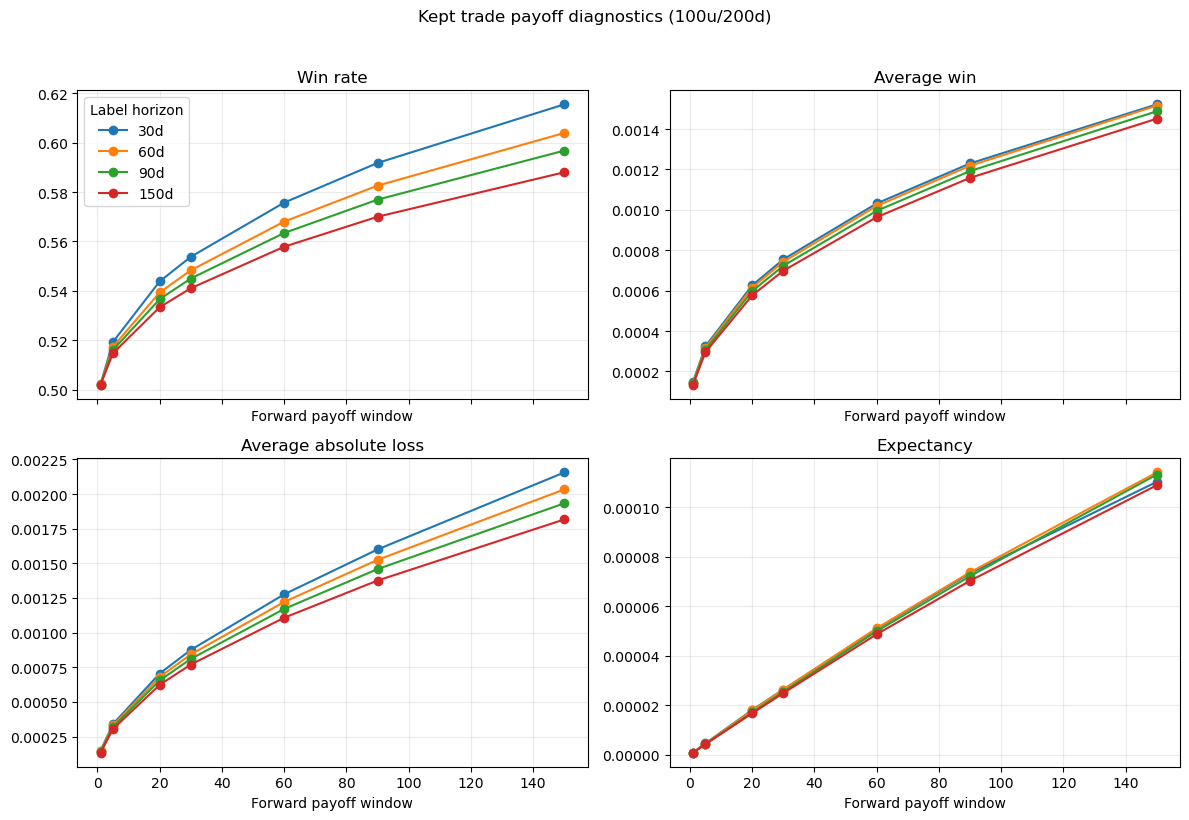

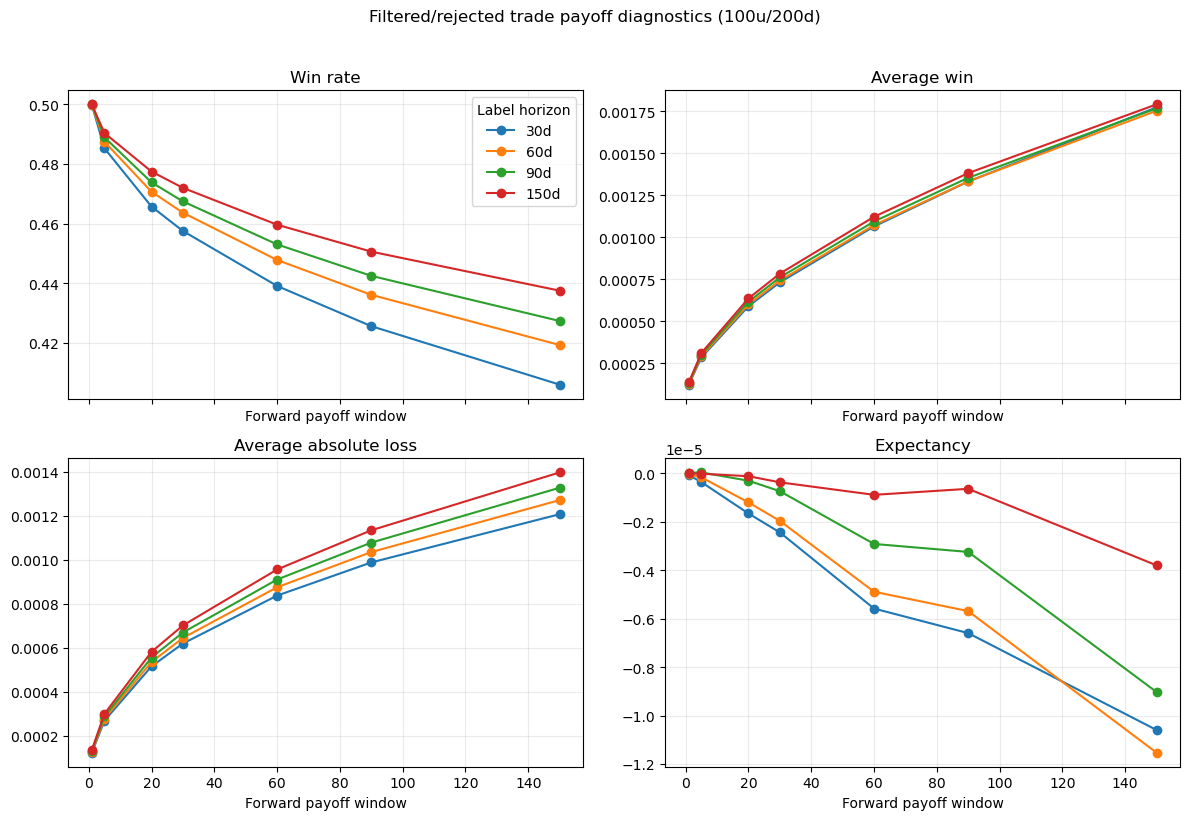

,horizon,window,win_rate,avg_win,avg_abs_loss,expectancy
0,30,1,0.5021,0.0001,0.0001,0.0000
1,30,5,0.5193,0.0003,0.0003,0.0000
2,30,20,0.5438,0.0006,0.0007,0.0000
3,30,30,0.5538,0.0008,0.0009,0.0000
4,30,60,0.5758,0.0010,0.0013,0.0001
5,30,90,0.5918,0.0012,0.0016,0.0001
6,30,150,0.6156,0.0015,0.0022,0.0001
7,60,1,0.5021,0.0001,0.0001,0.0000
8,60,5,0.5173,0.0003,0.0003,0.0000
9,60,20,0.5393,0.0006,0.0007,0.0000


In [163]:
expectancy_weight = expectancy_results[expectancy_results["payoff_type"] == "weight"]

kept_payoff_mean = plot_payoff_panel(
    summary_df=expectancy_weight,
    title=f"Kept trade payoff diagnostics ({scenario_name})",
    group_col="decision",
    group_value="kept",
)

filtered_payoff_mean = plot_payoff_panel(
    summary_df=expectancy_weight,
    title=f"Filtered/rejected trade payoff diagnostics ({scenario_name})",
    group_col="decision",
    group_value="filtered",
)

kept_payoff_mean.head(12)

## Payoff Diagnostics By Confusion Group

The next four plots show payoff diagnostics separately for TP, FP, TN, and FN trades.

### Why This Matters

A single confusion-matrix count does not show whether errors are economically meaningful. For example:

- many false positives may be acceptable if their losses are tiny
- a small number of false positives can be damaging if their losses are large
- false negatives are costly only if the rejected positive-label trades would have produced meaningful payoff
- true negatives are valuable if they represent avoided losses

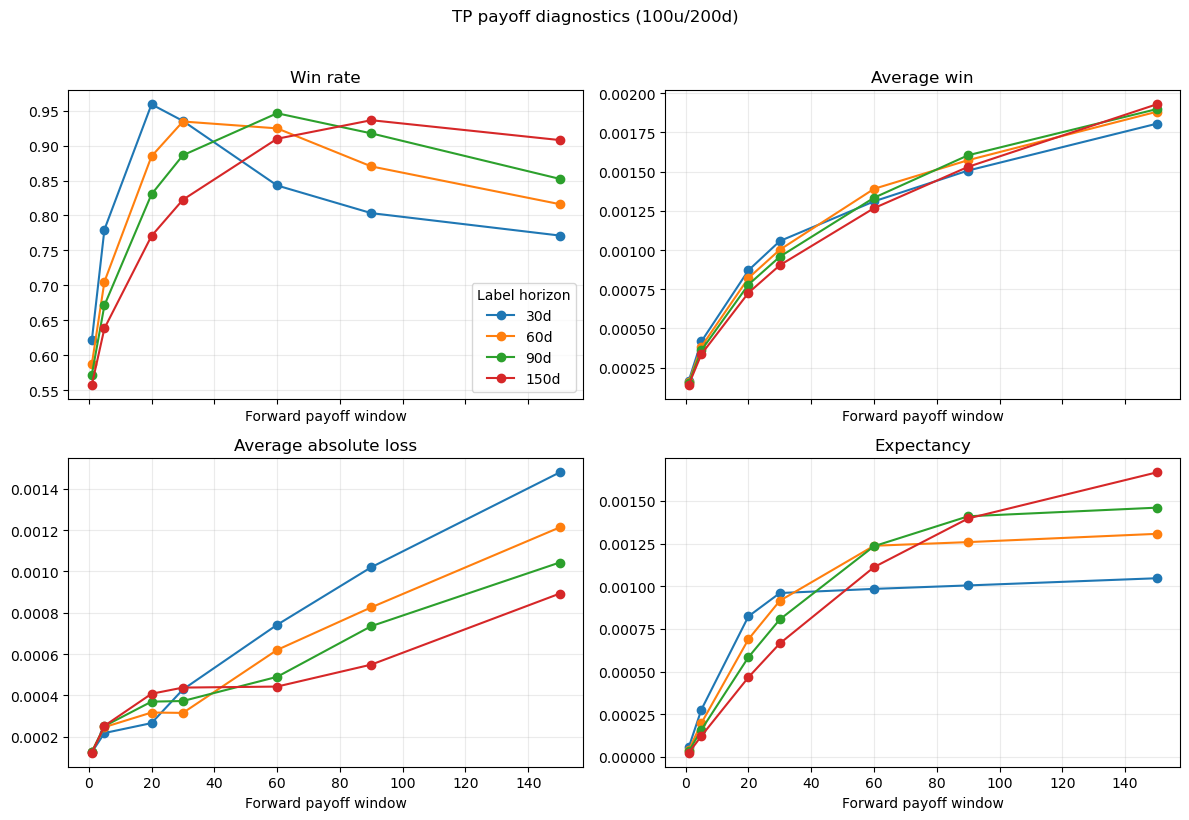

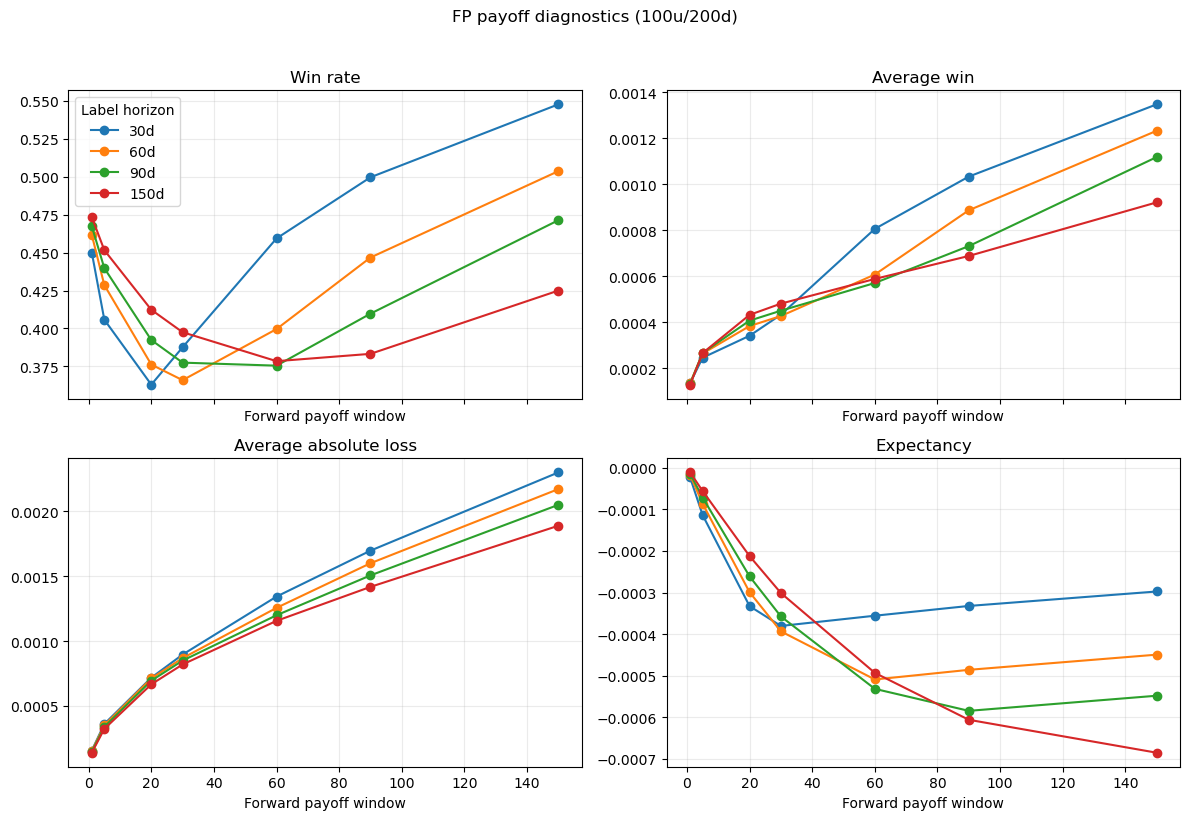

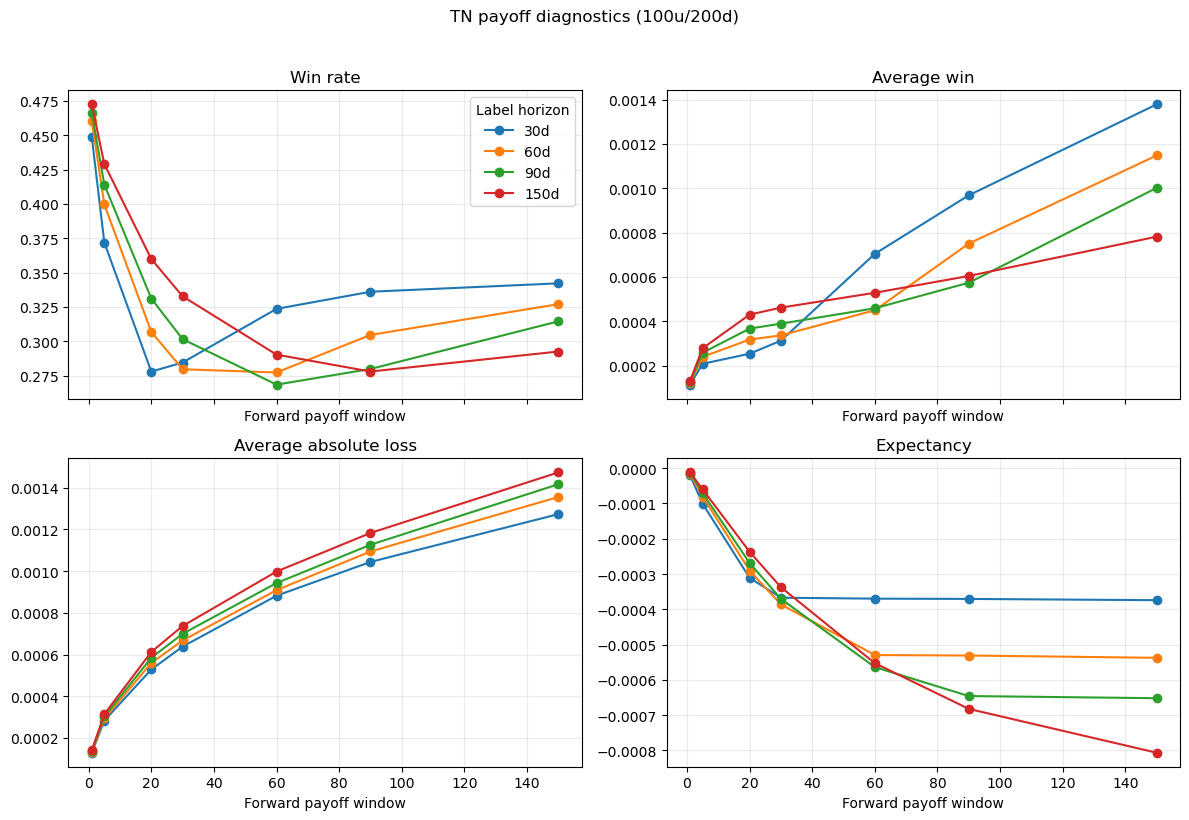

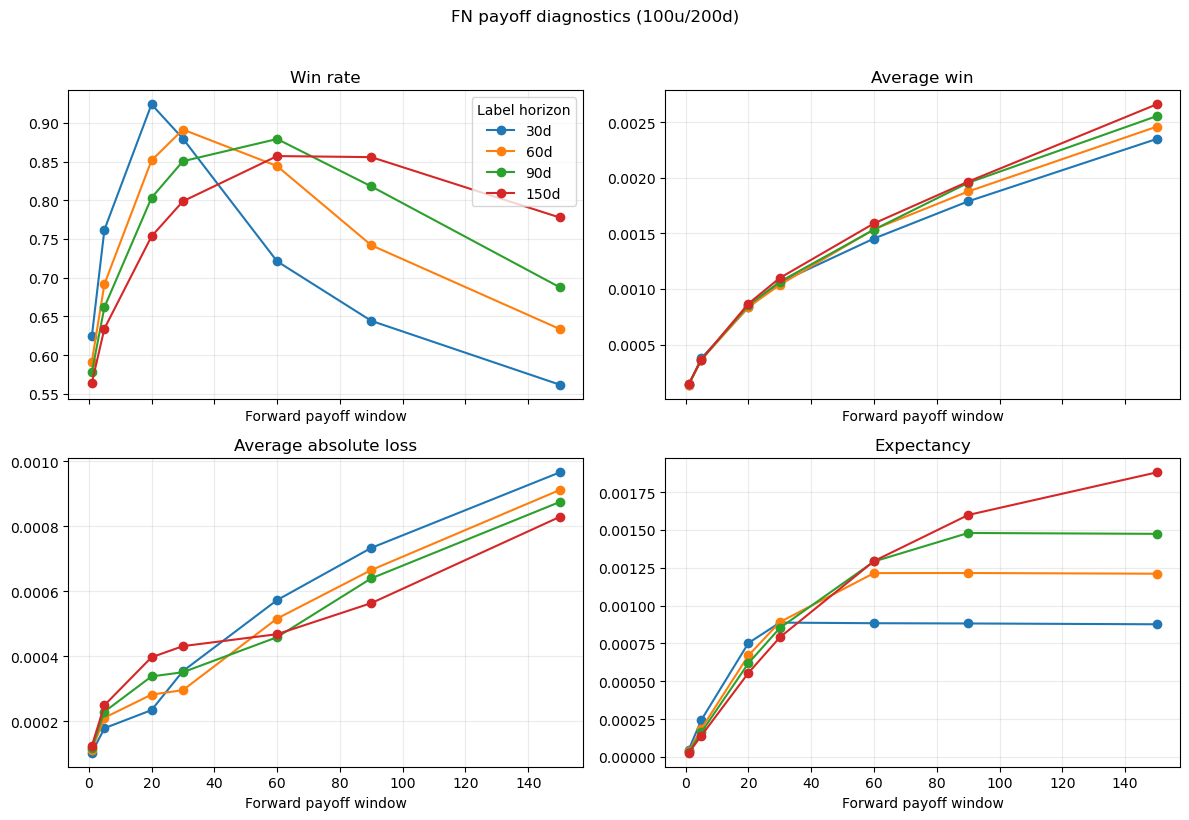

,horizon,window,win_rate,avg_win,avg_abs_loss,expectancy
0,30,1,0.4500,0.0001,0.0002,-0.0000
1,30,5,0.4058,0.0002,0.0004,-0.0001
2,30,20,0.3630,0.0003,0.0007,-0.0003
3,30,30,0.3876,0.0004,0.0009,-0.0004
4,30,60,0.4594,0.0008,0.0013,-0.0004
5,30,90,0.4997,0.0010,0.0017,-0.0003
6,30,150,0.5478,0.0013,0.0023,-0.0003
7,60,1,0.4617,0.0001,0.0001,-0.0000
8,60,5,0.4286,0.0003,0.0004,-0.0001
9,60,20,0.3762,0.0004,0.0007,-0.0003


In [164]:
confusion_weight = confusion_payoff_results[confusion_payoff_results["payoff_type"] == "weight"]

confusion_group_means = {}
for group in ["TP", "FP", "TN", "FN"]:
    confusion_group_means[group] = plot_payoff_panel(
        summary_df=confusion_weight,
        title=f"{group} payoff diagnostics ({scenario_name})",
        group_col="confusion_group",
        group_value=group,
    )

confusion_group_means["FP"].head(12)

## One-Day False Positives, Missed Winners, And Avoided Losers

This section keeps the earlier 1-day view because it connects directly to daily portfolio evaluation.

- **False positives** are negative-label trades that were kept.
- **False negatives** are positive-label trades that were filtered.
- **True negatives** are negative-label trades that were filtered.
- **True positives** are positive-label trades that were kept.

The multi-window plots above show timing. The 1-day table below shows the immediate daily-rebalanced implication.

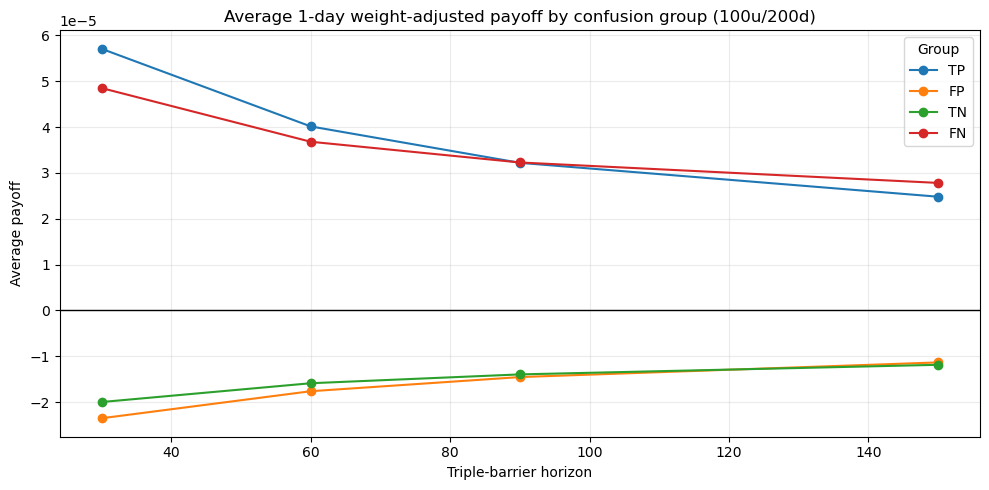

,horizon,confusion_group,n,avg_payoff,total_payoff,win_rate,expectancy
0,30,FN,182670.4500,0.0000,8.8544,0.6246,0.0000
1,30,FP,408032.2500,-0.0000,-9.5924,0.4500,-0.0000
2,30,TN,445519.3000,-0.0000,-8.8988,0.4486,-0.0000
3,30,TP,177778.0000,0.0001,10.1375,0.6218,0.0001
4,60,FN,190553.6000,0.0000,7.0092,0.5917,0.0000
5,60,FP,391765.5500,-0.0000,-6.9049,0.4617,-0.0000
6,60,TN,442611.4000,-0.0000,-7.0296,0.4603,-0.0000
7,60,TP,185069.4500,0.0000,7.4257,0.5876,0.0000
8,90,FN,192256.6000,0.0000,6.2070,0.5777,0.0000
9,90,FP,382784.7500,-0.0000,-5.5682,0.4674,-0.0000


In [165]:
confusion_weight_1d = confusion_payoff_results[
    (confusion_payoff_results["window"] == 1)
    & (confusion_payoff_results["payoff_type"] == "weight")
]

confusion_weight_summary = (
    confusion_weight_1d
    .groupby(["horizon", "confusion_group"])[[
        "n",
        "avg_payoff",
        "total_payoff",
        "win_rate",
        "expectancy",
    ]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for group in ["TP", "FP", "TN", "FN"]:
    data = confusion_weight_summary[confusion_weight_summary["confusion_group"] == group]
    ax.plot(data["horizon"], data["avg_payoff"], marker="o", label=group)

ax.axhline(0.0, color="black", linewidth=1)
ax.set_title(f"Average 1-day weight-adjusted payoff by confusion group ({scenario_name})")
ax.set_xlabel("Triple-barrier horizon")
ax.set_ylabel("Average payoff")
ax.legend(title="Group")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

confusion_weight_summary

## Long And Short Side Diagnostics

The secondary model does not directly decide whether to go long or short. It predicts whether to keep or reject the trade proposed by the primary strategy.

Therefore, if the secondary portfolio becomes strongly net-long or net-short after filtering and gross-exposure normalisation, the source of the imbalance has to be diagnosed separately.

### Diagnostics In This Section

The following quantities are computed separately for primary long and primary short candidates:

- kept rate
- positive-label rate
- average predicted probability
- average payoff of kept trades
- gross absolute weight reaching the filter
- gross absolute weight retained by the filter

These diagnostics help distinguish between model-side asymmetry and genuinely different long/short label quality.

In [166]:
side_weight_1d = side_results[
    (side_results["window"] == 1)
    & (side_results["payoff_type"] == "weight")
]

side_summary_1d = (
    side_weight_1d
    .groupby(["horizon", "primary_side"])[[
        "n_events",
        "kept_events",
        "kept_rate",
        "positive_label_rate",
        "avg_probability",
        "avg_abs_weight",
        "kept_abs_weight_share",
        "avg_kept_payoff",
        "total_kept_payoff",
    ]]
    .mean()
    .reset_index()
)

side_summary_1d

,horizon,primary_side,n_events,kept_events,kept_rate,positive_label_rate,avg_probability,avg_abs_weight,kept_abs_weight_share,avg_kept_payoff,total_kept_payoff
0,30,long,606149.5000,151534.4000,0.2500,0.2916,0.4940,0.0020,0.3713,0.0000,0.0543
1,30,short,607850.5000,434275.8500,0.7145,0.3022,0.5057,0.0020,0.8316,0.0000,0.4907
2,60,long,604133.6500,166214.5000,0.2751,0.3026,0.4920,0.0020,0.3877,0.0000,0.0580
3,60,short,605866.3500,410620.5000,0.6777,0.3183,0.5075,0.0020,0.7953,0.0000,0.4628
4,90,long,602349.2000,174759.3000,0.2901,0.3056,0.4904,0.0020,0.3911,0.0000,0.0527
5,90,short,604150.8000,395967.5500,0.6554,0.3246,0.5090,0.0020,0.7668,0.0000,0.4306
6,150,long,598599.5500,183557.7000,0.3066,0.3053,0.4877,0.0020,0.3932,0.0000,0.0672
7,150,short,600400.4500,376730.4000,0.6275,0.3288,0.5111,0.0020,0.7295,0.0000,0.4150


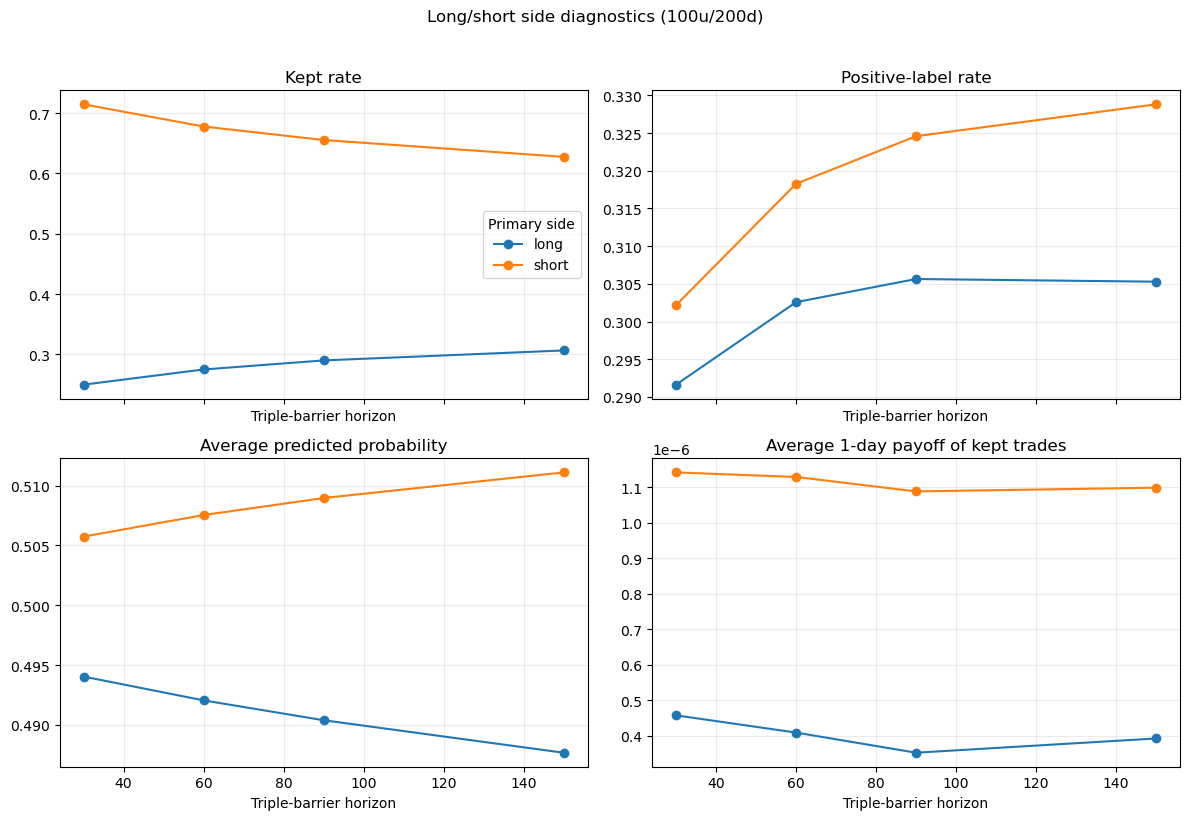

In [167]:
side_plot_metrics = [
    ("kept_rate", "Kept rate"),
    ("positive_label_rate", "Positive-label rate"),
    ("avg_probability", "Average predicted probability"),
    ("avg_kept_payoff", "Average 1-day payoff of kept trades"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (metric, title) in zip(axes.ravel(), side_plot_metrics):
    for primary_side in ["long", "short"]:
        data = side_summary_1d[side_summary_1d["primary_side"] == primary_side]
        ax.plot(data["horizon"], data[metric], marker="o", label=primary_side)
    ax.set_title(title)
    ax.set_xlabel("Triple-barrier horizon")
    ax.grid(alpha=0.25)

axes[0, 0].legend(title="Primary side")
fig.suptitle(f"Long/short side diagnostics ({scenario_name})", y=1.02)
fig.tight_layout()
plt.show()

## Economic Metric Link

This table links classification quality, event-level payoff diagnostics, and portfolio-level economics.

The central question is whether better label ranking appears as:

- better kept-trade expectancy
- lower false-positive cost
- fewer missed winners
- better Sharpe or return
- acceptable drawdown and turnover

In [168]:
horizon_classification = (
    classification_results
    .groupby("horizon")[["roc_auc", "base_positive_rate", "positive_rate_among_kept", "fraction_kept"]]
    .mean()
)

horizon_strategy = (
    strategy_results
    .groupby("horizon")[["delta_ann_return", "delta_sharpe", "delta_max_drawdown", "delta_ann_turnover"]]
    .mean()
)

kept_weight_1d = expectancy_results[
    (expectancy_results["decision"] == "kept")
    & (expectancy_results["payoff_type"] == "weight")
    & (expectancy_results["window"] == 1)
]
kept_weight_1d = kept_weight_1d.groupby("horizon")[["win_rate", "avg_win", "avg_abs_loss", "expectancy"]].mean()
kept_weight_1d = kept_weight_1d.add_prefix("kept_1d_")

fp_weight_1d = confusion_weight_1d[confusion_weight_1d["confusion_group"] == "FP"]
fp_weight_1d = fp_weight_1d.groupby("horizon")[["avg_payoff", "total_payoff"]].mean()
fp_weight_1d = fp_weight_1d.rename(columns={
    "avg_payoff": "fp_1d_avg_payoff",
    "total_payoff": "fp_1d_total_payoff",
})

filtered_positive_1d = filtering_1d[
    (filtering_1d["decision"] == "filtered")
    & (filtering_1d["label_group"] == "positive_label")
]
filtered_positive_1d = filtered_positive_1d.groupby("horizon")[["avg_filtering_effect", "total_filtering_effect"]].mean()
filtered_positive_1d = filtered_positive_1d.rename(columns={
    "avg_filtering_effect": "missed_winner_1d_avg_effect",
    "total_filtering_effect": "missed_winner_1d_total_effect",
})

filtered_negative_1d = filtering_1d[
    (filtering_1d["decision"] == "filtered")
    & (filtering_1d["label_group"] == "negative_label")
]
filtered_negative_1d = filtered_negative_1d.groupby("horizon")[["avg_filtering_effect", "total_filtering_effect"]].mean()
filtered_negative_1d = filtered_negative_1d.rename(columns={
    "avg_filtering_effect": "avoided_loser_1d_avg_effect",
    "total_filtering_effect": "avoided_loser_1d_total_effect",
})

sensitivity_link = pd.concat(
    [
        horizon_classification,
        kept_weight_1d,
        fp_weight_1d,
        filtered_positive_1d,
        filtered_negative_1d,
        horizon_strategy,
    ],
    axis=1,
)

sensitivity_link

,roc_auc,base_positive_rate,positive_rate_among_kept,fraction_kept,kept_1d_win_rate,kept_1d_avg_win,kept_1d_avg_abs_loss,kept_1d_expectancy,fp_1d_avg_payoff,fp_1d_total_payoff,missed_winner_1d_avg_effect,missed_winner_1d_total_effect,avoided_loser_1d_avg_effect,avoided_loser_1d_total_effect,delta_ann_return,delta_sharpe,delta_max_drawdown,delta_ann_turnover
horizon,,,,,,,,,,,,,,,,,,
30,0.5111,0.2969,0.3035,0.4825,0.5021,0.0001,0.0001,0.0000,-0.0000,-9.5924,-0.0000,-8.8544,0.0000,8.8988,0.0437,0.2477,-0.0057,1.6962
60,0.5171,0.3104,0.3208,0.4767,0.5021,0.0001,0.0001,0.0000,-0.0000,-6.9049,-0.0000,-7.0092,0.0000,7.0296,0.0405,0.2350,-0.0207,1.7604
90,0.5228,0.3151,0.3293,0.4730,0.5020,0.0001,0.0001,0.0000,-0.0000,-5.5682,-0.0000,-6.2070,0.0000,6.1914,0.0356,0.2041,-0.0210,1.7316
150,0.5320,0.3171,0.3377,0.4673,0.5020,0.0001,0.0001,0.0000,-0.0000,-4.2114,-0.0000,-5.3125,0.0000,5.3135,0.0411,0.2717,-0.0141,1.6470


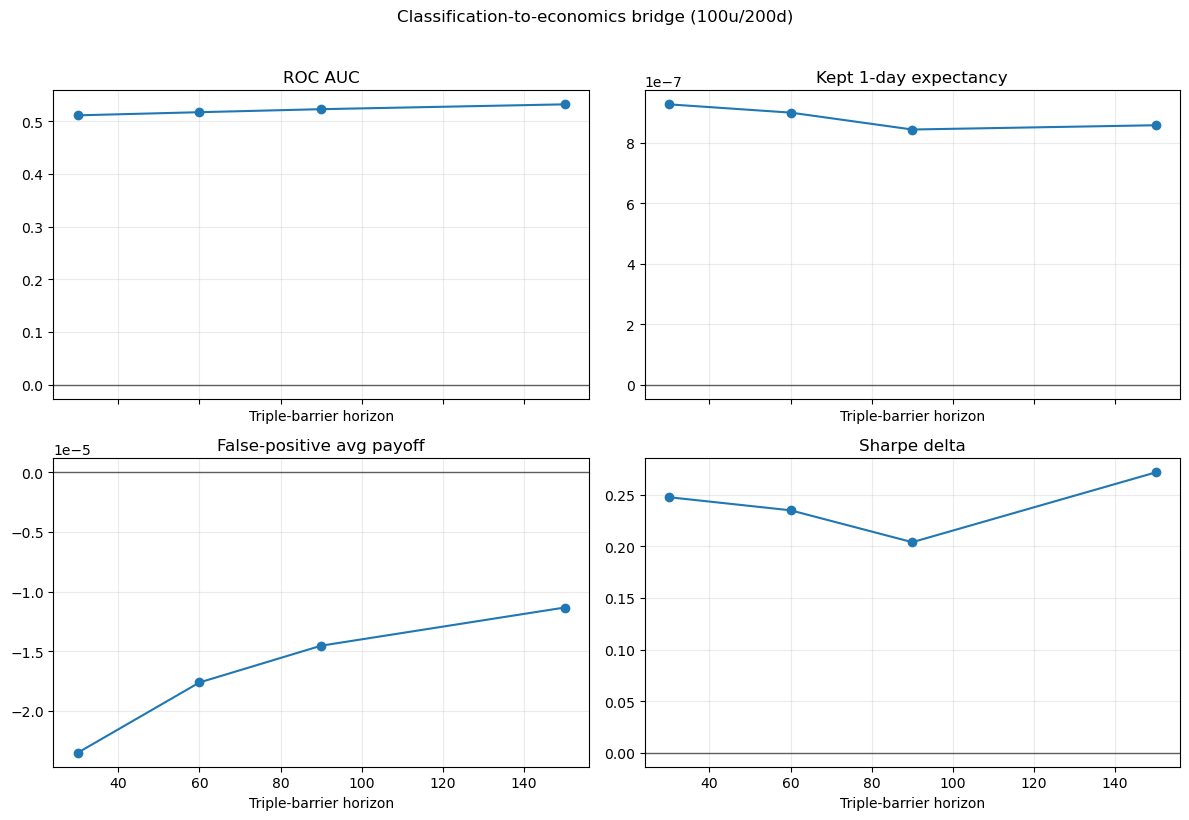

In [169]:
link_plot_cols = [
    ("roc_auc", "ROC AUC"),
    ("kept_1d_expectancy", "Kept 1-day expectancy"),
    ("fp_1d_avg_payoff", "False-positive avg payoff"),
    ("delta_sharpe", "Sharpe delta"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (col, title) in zip(axes.ravel(), link_plot_cols):
    ax.plot(sensitivity_link.index, sensitivity_link[col], marker="o")
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Triple-barrier horizon")
    ax.grid(alpha=0.25)

fig.suptitle(f"Classification-to-economics bridge ({scenario_name})", y=1.02)
fig.tight_layout()
plt.show()

## Exposure Diagnostics

### Primary Strategy

The primary strategy is expected to be close to dollar-neutral because the cross-sectional signal is demeaned before gross normalisation.

### Secondary Gross-Normalised Strategy

The secondary strategy shown here is gross-exposure normalised, but it is not forced to be dollar-neutral after filtering.

### Why This Matters

If the secondary filter keeps mostly long trades, gross normalisation can turn the strategy into a long-biased portfolio. If it keeps mostly short trades, it can become short-biased. This means economic performance may reflect exposure drift rather than pure meta-labeling skill.

In [170]:
exposure_mean = (
    exposure_results
    .groupby(["horizon", "strategy"])[[
        "net_exposure",
        "gross_exposure",
        "long_exposure",
        "short_exposure",
        "long_gross_share",
        "short_gross_share",
    ]]
    .mean()
    .reset_index()
)

exposure_mean

,horizon,strategy,net_exposure,gross_exposure,long_exposure,short_exposure,long_gross_share,short_gross_share
0,30,primary,-0.0000,1.0000,0.5000,-0.5000,0.5000,0.5000
1,30,secondary_gross,-0.3932,1.0000,0.3034,-0.6966,0.3034,0.6966
2,60,primary,-0.0000,1.0000,0.5000,-0.5000,0.5000,0.5000
3,60,secondary_gross,-0.3496,1.0000,0.3252,-0.6748,0.3252,0.6748
4,90,primary,-0.0000,1.0000,0.5000,-0.5000,0.5000,0.5000
5,90,secondary_gross,-0.3265,1.0000,0.3367,-0.6633,0.3367,0.6633
6,150,primary,-0.0000,1.0000,0.5000,-0.5000,0.5000,0.5000
7,150,secondary_gross,-0.3003,1.0000,0.3499,-0.6501,0.3499,0.6501


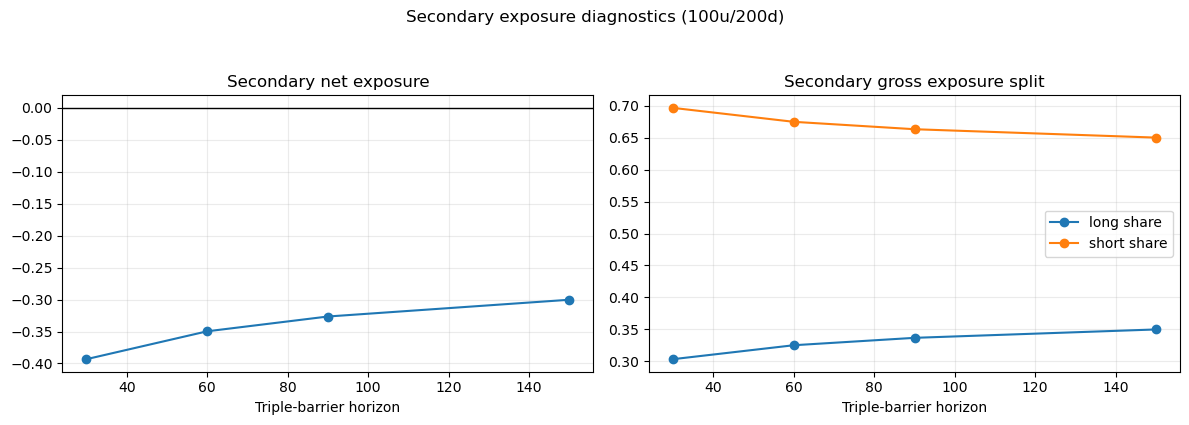

In [171]:
secondary_exposure = exposure_mean[exposure_mean["strategy"] == "secondary_gross"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(secondary_exposure["horizon"], secondary_exposure["net_exposure"], marker="o")
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Secondary net exposure")
axes[0].set_xlabel("Triple-barrier horizon")
axes[0].grid(alpha=0.25)

axes[1].plot(secondary_exposure["horizon"], secondary_exposure["long_gross_share"], marker="o", label="long share")
axes[1].plot(secondary_exposure["horizon"], secondary_exposure["short_gross_share"], marker="o", label="short share")
axes[1].set_title("Secondary gross exposure split")
axes[1].set_xlabel("Triple-barrier horizon")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle(f"Secondary exposure diagnostics ({scenario_name})", y=1.05)
fig.tight_layout()
plt.show()

In [ ]:
## Interpretation Guide

Use the tables and plots above to write the horizon-sensitivity conclusion carefully.

### Classification

Longer horizons may produce clearer labels, but the labels are not the same target as shorter-horizon labels.

### Payoff Timing

Better ROC AUC is economically useful only if it improves kept-trade expectancy at the relevant payoff window. A daily-rebalanced strategy may not benefit much from a label whose signal appears mainly over longer windows.

### Filtering Quality

Meta-labeling should be judged by both kept and filtered trades. The model can add value by keeping good trades or by rejecting bad trades. It can lose value by keeping bad trades or rejecting good trades.

### Side And Exposure

If gross-exposure normalisation creates a strong long or short bias, the resulting economic performance may depend heavily on the simulated drift asymmetry. This is why the long/short diagnostics are essential before interpreting the secondary model as a robust improvement.

### Current Next Step

This run tests whether the log-space triple-barrier construction is enough when using the original `weight`, `ret_150`, `vol_150` feature set. If a strong side bias remains, the next candidate is either explicit side-aware features or a separated long-side and short-side secondary model.